# Phase 5 -- HMM POS tagging (regional language: Hindi)

Lab experiment reusing the exact same `HMMTagger` class from Phase 4 --
no Hindi-specific subclass, no separate training code. Only the corpus
and the (already-built) Devanagari branch of `_guess_tag_by_suffix`
differ. That reuse is the whole point of this phase's design.

**A note on tagset choice**: this sandbox has no network access to
download NLTK's real `indian` corpus, so the sample data below is
hand-tagged using the *same* 12-tag Universal POS tagset as Phase 4's
English corpus -- which makes the accuracy numbers directly comparable
in section 5. The real `nltk.corpus.indian` corpus uses its own native
tagset (the IIIT-Hyderabad scheme), not Universal tags. The
`CORPUS_SOURCE = "nltk"` branch below trains directly on those native
tags (no mapping attempted -- a mapping table risked being wrong
without a way to verify it here) -- accuracy-vs-baseline is still a
fair comparison in *kind*, just not tag-for-tag against English.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import random
import matplotlib.pyplot as plt
import numpy as np

from nticipate.config import load_config, resolve_path
from nticipate.hmm import HMMTagger
from nticipate.preprocess import clean_text, segment_sentences, tokenize

CFG = load_config()
CORPUS_SOURCE = "sample"   # "sample" (ships in repo) or "nltk" (after setup_env.py)
LANGUAGE = CFG["hmm"]["regional"]["language"]  # "hindi" by default

## 1. Load the Hindi tagged corpus and split

In [2]:
def load_conll(path):
    sentences, current = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line.strip():
                if current:
                    sentences.append(current)
                    current = []
                continue
            word, tag = line.split("\t")
            current.append((word, tag))
        if current:
            sentences.append(current)
    return sentences

if CORPUS_SOURCE == "sample":
    tagged_sentences = load_conll(resolve_path("data/raw/sample_tagged_hindi.conll"))
else:
    import nltk
    cfg = CFG["hmm"]["regional"]
    corpus = getattr(nltk.corpus, cfg["corpus"])
    tagged_sentences = corpus.tagged_sents(cfg["file"])  # native IIIT-H tagset, no mapping

rng = random.Random(CFG["project"]["seed"])
shuffled = list(tagged_sentences)
rng.shuffle(shuffled)
split_idx = int(len(shuffled) * CFG["preprocessing"]["train_split"])
hi_train = shuffled[:split_idx]
hi_test = shuffled[split_idx:]

print(f"Total sentences: {len(shuffled)}")
print(f"Train: {len(hi_train)}   Test: {len(hi_test)}")
print("Sample:", hi_train[0])

Total sentences: 35
Train: 28   Test: 7
Sample: [('मोहन', 'NOUN'), ('ने', 'ADP'), ('एक', 'NUM'), ('नई', 'ADJ'), ('किताब', 'NOUN'), ('खरीदी', 'VERB'), ('।', '.')]


## 2. Devanagari normalization

`preprocess.clean_text` already applies Unicode NFC normalization,
which composes accented/combining characters (including nukta
variants) consistently -- important since the same visual character
can arrive as different underlying codepoint sequences. `indic-nlp-library`
(in requirements.txt) offers more thorough nukta and chandrabindu
normalization for noisy/OCR'd text; this hand-typed sample corpus is
already clean, so the difference won't show here, but the check below
confirms which path is active.

In [3]:
try:
    from indicnlp.normalize.indic_normalize import DevanagariNormalizer
    normalizer = DevanagariNormalizer()
    sample = hi_train[0][0][0]
    print(f"indic-nlp-library available -- normalized sample: {normalizer.normalize(sample)!r}")
except ImportError:
    sample = hi_train[0][0][0]
    print("indic-nlp-library not installed in this environment.")
    print(f"Falling back to preprocess.clean_text's NFC normalization: {clean_text(sample)!r}")

indic-nlp-library available -- normalized sample: 'मोहन'


## 3. Train the tagger -- identical code path to Phase 4

In [4]:
hi_tagger = HMMTagger().fit(hi_train)
print(f"Tags learned ({len(hi_tagger.tags)}): {sorted(hi_tagger.tags)}")
print(f"Vocabulary size: {len(hi_tagger.vocab)}")

Tags learned (10): ['.', 'ADJ', 'ADP', 'ADV', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB']
Vocabulary size: 103


## 4. Accuracy: train vs. test, vs. baseline

In [5]:
hi_train_acc = hi_tagger.accuracy(hi_train)
hi_test_acc = hi_tagger.accuracy(hi_test)

most_common_tag = hi_tagger._most_common_tag()
total_test_tokens = sum(len(s) for s in hi_test)
baseline_correct = sum(1 for s in hi_test for _, t in s if t == most_common_tag)
hi_baseline_acc = baseline_correct / total_test_tokens if total_test_tokens else 0.0

print(f"Train accuracy:               {hi_train_acc:.3f}")
print(f"Test accuracy:                {hi_test_acc:.3f}")
print(f"Most-common-tag baseline ('{most_common_tag}'):  {hi_baseline_acc:.3f}")
print(f"Improvement over baseline:    {hi_test_acc - hi_baseline_acc:+.3f}")

Train accuracy:               0.863
Test accuracy:                0.674
Most-common-tag baseline ('NOUN'):  0.239
Improvement over baseline:    +0.435


## 5. Side-by-side: English (Phase 4) vs. Hindi (this phase)

Retrains the Phase 4 English tagger here too (cheap, and keeps this
comparison self-contained rather than depending on numbers copied from
another notebook) using the identical seed/split logic, so the two
columns below are a fair apples-to-apples comparison -- same tagset,
same train/test ratio, same smoothing constant.

In [6]:
en_conll_path = resolve_path("data/raw/sample_tagged_english.conll")
en_sentences = load_conll(en_conll_path)
en_shuffled = list(en_sentences)
random.Random(CFG["project"]["seed"]).shuffle(en_shuffled)
en_split = int(len(en_shuffled) * CFG["preprocessing"]["train_split"])
en_train, en_test = en_shuffled[:en_split], en_shuffled[en_split:]

en_tagger = HMMTagger().fit(en_train)
en_test_acc = en_tagger.accuracy(en_test)
en_most_common = en_tagger._most_common_tag()
en_total = sum(len(s) for s in en_test)
en_baseline_acc = sum(1 for s in en_test for _, t in s if t == en_most_common) / en_total

print(f"{'':28s}{'English':>12s}{'Hindi':>12s}")
print(f"{'Sentences (train/test)':28s}{f'{len(en_train)}/{len(en_test)}':>12s}{f'{len(hi_train)}/{len(hi_test)}':>12s}")
print(f"{'Vocab size':28s}{len(en_tagger.vocab):>12d}{len(hi_tagger.vocab):>12d}")
print(f"{'Test accuracy':28s}{en_test_acc:>12.3f}{hi_test_acc:>12.3f}")
print(f"{'Baseline accuracy':28s}{en_baseline_acc:>12.3f}{hi_baseline_acc:>12.3f}")
print(f"{'Improvement over baseline':28s}{en_test_acc-en_baseline_acc:>+12.3f}{hi_test_acc-hi_baseline_acc:>+12.3f}")

                                 English       Hindi
Sentences (train/test)              36/9        28/7
Vocab size                           142         103
Test accuracy                      0.780       0.674
Baseline accuracy                  0.254       0.239
Improvement over baseline         +0.525      +0.435


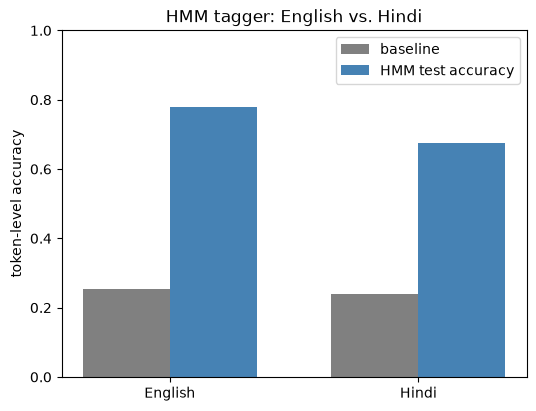

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [en_baseline_acc, hi_baseline_acc], width, label="baseline", color="gray")
ax.bar(x + width/2, [en_test_acc, hi_test_acc], width, label="HMM test accuracy", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(["English", "Hindi"])
ax.set_ylabel("token-level accuracy")
ax.set_ylim(0, 1)
ax.set_title("HMM tagger: English vs. Hindi")
ax.legend()
plt.show()

## 6. Morphological richness: TTR and OOV comparison

The hypothesis from the project plan: Hindi's inflectional morphology
(gender/number/case agreement on verbs, adjectives, postposition-
triggered case) should show up as a *higher* type-token ratio than
English on comparable raw text -- more distinct word forms per token,
because grammatical information that English marks with separate words
(or not at all) gets folded into the Hindi word itself.

In [8]:
def ttr_and_oov(raw_text_path, min_freq=2):
    with open(raw_text_path, encoding="utf-8") as f:
        raw_text = f.read()
    cleaned = clean_text(raw_text)
    sentences = [tokenize(s) for s in segment_sentences(cleaned)]
    all_tokens = [tok for sent in sentences for tok in sent]
    types = set(all_tokens)
    ttr = len(types) / len(all_tokens) if all_tokens else 0.0

    from collections import Counter
    freq = Counter(all_tokens)
    oov_rate = sum(1 for c in freq.values() if c < min_freq) / len(freq) if freq else 0.0
    return {
        "tokens": len(all_tokens),
        "types": len(types),
        "ttr": ttr,
        "oov_rate_at_min_freq": oov_rate,
    }

en_stats = ttr_and_oov(resolve_path("data/raw/sample_english.txt"))
hi_stats = ttr_and_oov(resolve_path("data/raw/sample_hindi.txt"))

print(f"{'':28s}{'English':>12s}{'Hindi':>12s}")
for key in ["tokens", "types", "ttr", "oov_rate_at_min_freq"]:
    en_v, hi_v = en_stats[key], hi_stats[key]
    fmt = "{:>12d}" if isinstance(en_v, int) else "{:>12.3f}"
    print(f"{key:28s}{fmt.format(en_v)}{fmt.format(hi_v)}")

                                 English       Hindi
tokens                               575         102
types                                296          68
ttr                                0.515       0.667
oov_rate_at_min_freq               0.767       0.838


**Caveat on this specific comparison**: the Hindi raw-text sample
(`sample_hindi.txt`) is much smaller than the English one
(`sample_english.txt`) -- TTR is corpus-size-sensitive (it falls as
corpus grows, since common words repeat), so a smaller corpus
mechanically inflates TTR regardless of morphology. This comparison is
suggestive, not conclusive, at this sample size; re-run on
similar-sized real corpora (Phase 1's `CORPUS_SOURCE = "nltk"` path for
English, the real `indian` corpus for Hindi) before treating the gap as
evidence of morphological richness rather than a sample-size artifact.

## 7. Validating the Devanagari suffix heuristic on OOV words

In [9]:
def unknown_word_suffix_accuracy(tagger, test_sentences):
    correct, total = 0, 0
    examples = []
    for sentence in test_sentences:
        for word, gold_tag in sentence:
            if word in tagger.vocab:
                continue  # only care about OOV words here
            guessed = tagger._guess_tag_by_suffix(word)
            total += 1
            is_correct = guessed == gold_tag
            correct += is_correct
            examples.append((word, gold_tag, guessed, is_correct))
    return (correct / total if total else None), total, examples

acc, n_oov, examples = unknown_word_suffix_accuracy(hi_tagger, hi_test)
if n_oov:
    print(f"Suffix-heuristic accuracy on {n_oov} OOV Hindi test words: {acc:.3f}")
    print()
    print(f"{'word':15s}{'gold':8s}{'guessed':8s}{'correct'}")
    for word, gold, guessed, is_correct in examples:
        print(f"{word:15s}{gold:8s}{guessed:8s}{is_correct}")
else:
    print("No OOV words in this test split -- corpus too small / lucky split.")
    print("Try re-running with a different CFG['project']['seed'] to see OOV cases.")

Suffix-heuristic accuracy on 23 OOV Hindi test words: 0.478

word           gold    guessed correct
तीन            NUM     NOUN    False
स्कूल          NOUN    NOUN    True
जाते           VERB    VERB    True
रोज            ADV     NOUN    False
स्कूल          NOUN    NOUN    True
जाती           VERB    VERB    True
सवाल           NOUN    NOUN    True
आसान           ADJ     NOUN    False
लड़की          NOUN    NOUN    True
पार्क          NOUN    NOUN    True
दौड़           VERB    NOUN    False
रही            VERB    NOUN    False
रोचक           ADJ     NOUN    False
फल             NOUN    NOUN    True
और             CONJ    NOUN    False
सब्जियां       NOUN    NOUN    True
खरीदीं         VERB    NOUN    False
सूरज           NOUN    NOUN    True
चमक            VERB    NOUN    False
रहा            VERB    NOUN    False
और             CONJ    NOUN    False
आसमान          NOUN    NOUN    True
साफ            ADJ     NOUN    False


**Why not just add more suffix rules?** Most misses above are verb forms ending in `ा`/`ी`/`ीं` (perfective/continuous markers: खरीदी "bought", रही "is/was [continuous]") that the Phase 4 rule list doesn't cover. Adding those endings would fix some of these cases -- but `ी` is *also* the standard feminine noun ending (लड़की "girl"), so the same rule would start misclassifying feminine nouns as verbs. This isn't a missing-rule problem, it's genuine morphological overlap: the same suffix marks different categories depending on the word. A larger hand-written rule list would trade one error type for another rather than actually improving coverage, and tuning rules against this specific 23-word test set would just be overfitting to a sample this small. A principled fix needs either substantially more training data (so fewer words are OOV in the first place) or a real morphological analyzer instead of suffix string-matching --  both out of scope for a from-scratch lab HMM, and worth naming as a limitation rather than papering over.


**A real limitation this can surface**: Hindi has words that are
lexically ambiguous between parts of speech independent of any
suffix rule -- "गाना" ("song", a noun) is identical in form to the
infinitive "गाना" ("to sing", a verb). The suffix heuristic always maps
`-ना` to VERB (the infinitive marker), so it will get the noun reading
wrong every time it appears. That's a genuine ceiling on suffix-only
heuristics, not a bug -- worth a sentence in the report alongside the
English "her" (DET/PRON) ambiguity from Phase 4.

## 8. Confusion pairs (Hindi)

In [10]:
hi_confusion = hi_tagger.confusion_pairs(hi_test)
hi_mistakes = {pair: count for pair, count in hi_confusion.items() if pair[0] != pair[1]}

print("Most confused (gold -> predicted) pairs on Hindi test set:")
for (gold, predicted), count in sorted(hi_mistakes.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  {gold:8s} -> {predicted:8s}  x{count}")
if not hi_mistakes:
    print("  (no mistakes on this small test set)")

Most confused (gold -> predicted) pairs on Hindi test set:
  VERB     -> NOUN      x4
  ADJ      -> NOUN      x3
  DET      -> PRON      x2
  NUM      -> NOUN      x1
  NOUN     -> ADP       x1
  ADV      -> NOUN      x1
  PRT      -> ADP       x1
  CONJ     -> NOUN      x1
  CONJ     -> .         x1


## Summary table (paste into report)

| Metric | English | Hindi |
|---|---|---|
| Vocab size | | |
| Test accuracy | | |
| Baseline accuracy | | |
| Improvement over baseline | | |
| Type-token ratio (raw sample) | | |

To run the Marathi variant instead: change `cfg["file"]` to
`"marathi.pos"` in section 1's `CORPUS_SOURCE == "nltk"` branch and
re-run from there -- the same `HMMTagger` class and every analysis cell
below it apply unchanged, per this phase's whole design premise.